# Thematic Alignment in Scientific Journals
## A Case Study on the Journal of Machine Learning Research (JMLR)

This notebook implements a full pipeline to quantitatively assess whether 
papers published in JMLR align with its stated Aims & Scope.

The pipeline consists of four main steps:
1. **Data Collection** — fetch paper abstracts from Semantic Scholar API
2. **Text Embedding** — encode abstracts and Aims & Scope using Sentence-BERT
3. **Alignment Scoring** — compute cosine similarity for each paper
4. **Topic Modeling** — discover latent themes using BERTopic

### Imports

In [39]:
import importlib
import src.visualizer
import src.topic_modeler
importlib.reload(src.visualizer)
importlib.reload(src.topic_modeler)
importlib.reload(src.scorer)

import os
import numpy as np
import pandas as pd
from dotenv import load_dotenv

from src.fetcher import SemanticScholarFetcher
from src.embedder import TextEmbedder
from src.scorer import AlignmentScorer
from src.visualizer import Visualizer

load_dotenv()
print("All imports OK")

All imports OK


## JMLR Aims & Scope

The Aims & Scope text serves as the **thematic reference** for the entire analysis.
It describes what JMLR is looking for: principled algorithms, theoretical studies,
new benchmarks, and mathematical frameworks for learning problems.

This text will be encoded into a single embedding vector that represents
the "ideal" thematic center of the journal.

In [2]:
with open("data/aims_and_scope.txt", "r") as f:
    aims_and_scope = f.read()

print("Aims & Scope loaded.")
print(aims_and_scope)

Aims & Scope loaded.
The Journal of Machine Learning Research (JMLR) provides an international 
forum for the electronic and paper publication of high-quality scholarly 
articles in all areas of machine learning. All published papers are freely 
available online. JMLR seeks previously unpublished papers on machine 
learning that contain: new principled algorithms with sound empirical 
validation; experimental and/or theoretical studies yielding new insight 
into the design and behavior of learning in intelligent systems; accounts 
of applications of existing techniques that shed light on the strengths 
and weaknesses of known approaches; formalization of new learning tasks 
and presentation of new benchmarks; and developments of new analytical 
frameworks that advance theoretical studies on the complexity, geometry, 
and other mathematical properties of learning problems and algorithms.


## Step 2 — Data Collection

**345 JMLR papers** published between 2015 and 2024 was collected using the 
Semantic Scholar Bulk Search API, filtering by venue = "Journal of Machine 
Learning Research".

Papers without abstracts were excluded, leaving a corpus of 345 documents
with an average abstract length of ~1226 characters.

Distribution by year:
- Growth visible from 2019 onwards (53 papers in 2020, 62 in 2021)
- Slight drop in 2024 likely due to incomplete indexing

In [3]:
key = os.getenv("S2_API_KEY")

fetcher = SemanticScholarFetcher(
    venue="Journal of Machine Learning Research",
    year_start=2015,
    year_end=2024,
    api_key=key
)

df = fetcher.fetch(max_papers=1000)
fetcher.save(df, path="data/abstracts.csv")

print(f"\nDataset shape: {df.shape}")
print(df["year"].value_counts().sort_index())

Fetching papers from 'Journal of Machine Learning Research' (2015–2024)...
  Collected: 345 papers
Done.

Total papers collected: 345
Saved to data/abstracts.csv

Dataset shape: (345, 5)
year
2015    24
2016    21
2017    20
2018    29
2019    32
2020    53
2021    62
2022    39
2023    43
2024    22
Name: count, dtype: int64


### Load Data

In [4]:
df = pd.read_csv("data/abstracts.csv")
print(f"Dataset loaded: {df.shape}")
print(df["year"].value_counts().sort_index())

Dataset loaded: (345, 5)
year
2015    24
2016    21
2017    20
2018    29
2019    32
2020    53
2021    62
2022    39
2023    43
2024    22
Name: count, dtype: int64


## Text Embedding with Sentence-BERT

Each abstract and the Aims & Scope text are encoded using 
**`all-MiniLM-L6-v2`**, a lightweight Sentence-BERT model that maps 
text into a 384-dimensional vector space.

The key property of these embeddings is that **semantically similar texts 
produce vectors that are geometrically close**. For example:

- *"The Bayesian Learning Rule"* → vector close to the Aims & Scope vector
- *"depyf: Open the Opaque Box of PyTorch Compiler"* → vector far from it

This gives us a 345×384 matrix of abstract embeddings and a single 
384-dimensional vector for the Aims & Scope.

In [34]:
embedder = TextEmbedder(model_name="all-MiniLM-L6-v2")

abstract_embeddings = embedder.encode_from_df(df, text_col="abstract")
scope_embedding = embedder.encode([aims_and_scope])[0]

embedder.save_embeddings(abstract_embeddings, path="data/embeddings.npy")
np.save("data/scope_embedding.npy", scope_embedding)

print(f"Abstracts embeddings: {abstract_embeddings.shape}")
print(f"Scope embedding: {scope_embedding.shape}")

Loading model: all-MiniLM-L6-v2...
Model loaded.


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embeddings saved to data/embeddings.npy
Abstracts embeddings: (345, 384)
Scope embedding: (384,)


### Load Embeddings

In [6]:
abstract_embeddings = np.load("data/embeddings.npy")
scope_embedding = np.load("data/scope_embedding.npy")
print(f"Embeddings loaded: {abstract_embeddings.shape}")

Embeddings loaded: (345, 384)


## Alignment Scoring

The alignment score for each paper is computed as the **cosine similarity** 
between its embedding and the Aims & Scope embedding:

$$\text{score}(p) = \frac{\vec{e}_p \cdot \vec{e}_{scope}}{||\vec{e}_p|| \cdot ||\vec{e}_{scope}||}$$

A score of 1.0 means perfect alignment; 0.0 means orthogonal (unrelated).

Across our 345 JMLR papers:
- Mean score: **0.377** — moderate but consistent alignment
- Std: **0.068** — relatively tight distribution
- Range: 0.123 – 0.602

In [42]:
scorer = AlignmentScorer(scope_embedding=scope_embedding)
scores = scorer.compute_scores(abstract_embeddings)
df = scorer.add_scores_to_df(df, scores)

print(f"Mean:  {df['alignment_score'].mean():.4f}")
print(f"Std:   {df['alignment_score'].std():.4f}")
print(f"Min:   {df['alignment_score'].min():.4f}")
print(f"Max:   {df['alignment_score'].max():.4f}")

Mean:  0.3774
Std:   0.0679
Min:   0.1230
Max:   0.6022


## Outlier Analysis

We identify the 5 most and least aligned papers to validate the metric 
through qualitative inspection.

**Most aligned** papers are core ML theory works:
- *The Bayesian Learning Rule* (0.602) — directly addresses learning algorithms
- *Approximate Newton Methods* (0.526) — optimization for ML systems

**Least aligned** papers tend to be:
- Software toolkits: *Seglearn*, *depyf* — focused on implementation, not theory
- Domain-specific applications: *Extracting PICO Sentences from Clinical Trials*
- Pure mathematics with weak ML connection: *Tensor Perturbation Bounds*

This confirms that the metric correctly distinguishes core JMLR content 
from peripheral contributions.

In [8]:
top, bottom = scorer.get_outliers(df, n=5)

print("TOP 5 — Most aligned:")
print(top[["title", "year", "alignment_score"]].to_string(index=False))

print("\nBOTTOM 5 — Least aligned:")
print(bottom[["title", "year", "alignment_score"]].to_string(index=False))

TOP 5 — Most aligned:
                                                         title  year  alignment_score
                                    The Bayesian Learning Rule  2021         0.602234
           Distributed Learning with Regularized Least Squares  2016         0.560884
                                    Approximate Newton Methods  2017         0.525894
Optimal Rates of Distributed Regression with Imperfect Kernels  2020         0.519323
              An Entropy-Based Model for Hierarchical Learning  2022         0.508918

BOTTOM 5 — Least aligned:
                                                                                               title  year  alignment_score
                                   Seglearn: A Python Package for Learning Sequences and Time Series  2018         0.224996
                                A Sharp Blockwise Tensor Perturbation Bound for Orthogonal Iteration  2020         0.202811
          Extracting PICO Sentences from Clinical Trial Reports

### Formal Outlier Detection

To identify papers that are significantly misaligned with the journal's scope,
we define a formal threshold based on the score distribution:

$$\text{threshold} = \mu - 1.5 \times \sigma = 0.377 - 1.5 \times 0.068 = 0.275$$

Papers scoring below this threshold are classified as **outliers** — their content
deviates substantially from the journal's stated mission. The choice of 1.5σ captures
approximately the bottom 7–8% of a normal distribution, corresponding to papers that
are genuinely unusual rather than just slightly below average.

Among the 28 outliers identified, several patterns emerge:
- **Software toolkits** with no theoretical contribution: *Seglearn*, *depyf*, *GraSPy*
- **Domain-specific applications** far from core ML: *Extracting PICO Sentences from Clinical Trials*
- **Pure mathematics** with weak ML connection: *Tensor Perturbation Bounds*, *Persistence Landscapes*
- **Methodology papers** from adjacent fields: *Post-Hoc Tests Based on Mean-Ranks*, *Instrumental Variable Models*

In [9]:
threshold = df["alignment_score"].mean() - 1.5 * df["alignment_score"].std()
outliers = df[df["alignment_score"] < threshold]

print(f"Mean:      {df['alignment_score'].mean():.3f}")
print(f"Std:       {df['alignment_score'].std():.3f}")
print(f"Threshold: {threshold:.3f}  (mean - 1.5 × std)")
print(f"Outliers:  {len(outliers)} papers ({len(outliers)/len(df)*100:.1f}%)")
print(f"Normal:    {len(df) - len(outliers)} papers ({(len(df)-len(outliers))/len(df)*100:.1f}%)")

print("\nOutlier papers (sorted by score):")
print(
    outliers[["title", "year", "alignment_score"]]
    .sort_values("alignment_score")
    .to_string(index=False)
)

Mean:      0.377
Std:       0.068
Threshold: 0.275  (mean - 1.5 × std)
Outliers:  28 papers (8.1%)
Normal:    317 papers (91.9%)

Outlier papers (sorted by score):
                                                                                                                          title  year  alignment_score
                                                depyf: Open the Opaque Box of PyTorch Compiler for Machine Learning Researchers  2024         0.122980
                           Consensus-based Optimization on the Sphere II: Convergence to Global Minimizers and Machine Learning  2020         0.189621
                                     Extracting PICO Sentences from Clinical Trial Reports using Supervised Distant Supervision  2016         0.202104
                                                           A Sharp Blockwise Tensor Perturbation Bound for Orthogonal Iteration  2020         0.202811
                                                              Seglearn: A Python 

### Thematic Drift Analysis

To detect whether JMLR's editorial focus has shifted over the decade,
we compare the mean alignment score between two periods:

- **Early period (2015–2019):** the first five years of our corpus
- **Late period (2020–2024):** the most recent five years

A negative difference would indicate that more recent papers are drifting
away from the journal's stated scope.

In our case, the difference is only **−0.001** — essentially negligible.
This suggests that JMLR maintains a remarkably stable thematic identity
over the decade, with no significant editorial drift detectable through
embedding-based alignment scoring.

This contrasts with journals in more interdisciplinary fields (e.g.,
Ecological Economics) where drift tends to be more pronounced due to
the inherently broader and evolving scope of the field.

In [10]:
early = df[df["year"] <= 2019]["alignment_score"].mean()
late = df[df["year"] > 2019]["alignment_score"].mean()

print(f"Early period (2015–2019): {early:.3f}")
print(f"Late period  (2020–2024): {late:.3f}")
print(f"Difference:               {late - early:.3f}")

Early period (2015–2019): 0.378
Late period  (2020–2024): 0.377
Difference:               -0.001


## Topic Modeling with BERTopic

BERTopic is applied to discover latent thematic clusters in the corpus.
It uses the precomputed Sentence-BERT embeddings (avoiding redundant computation),
HDBSCAN for clustering, and c-TF-IDF for topic representation.

We set `min_cluster_size=5` and `nr_topics=10` to extract meaningful 
but not overly granular topics from our 345-paper corpus.

In [31]:
from src.topic_modeler import TopicModeler

topic_modeler = TopicModeler(n_topics=10)
abstracts = df["abstract"].fillna("").tolist()
topics, probs = topic_modeler.fit(abstracts=abstracts, embeddings=abstract_embeddings)
df = topic_modeler.add_topics_to_df(df)
topic_model = topic_modeler.model

print(f"Topics found: {topic_modeler.get_topic_info().shape[0]}")
topic_modeler.get_topic_info()

2026-06-27 21:34:06,514 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


2026-06-27 21:34:06,903 - BERTopic - Dimensionality - Completed ✓
2026-06-27 21:34:06,904 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-27 21:34:06,964 - BERTopic - Cluster - Completed ✓
2026-06-27 21:34:06,964 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-27 21:34:07,174 - BERTopic - Representation - Completed ✓
2026-06-27 21:34:07,175 - BERTopic - Topic reduction - Reducing number of topics
2026-06-27 21:34:07,188 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-27 21:34:07,451 - BERTopic - Representation - Completed ✓
2026-06-27 21:34:07,454 - BERTopic - Topic reduction - Reduced number of topics from 50 to 10


Topics found: 10


,Topic,Count,Name,Representation,Representative_Docs
0,-1,35,-1_learning_data_machine_machine learning,"[learning, data, machine, machine learning, pr...",[While momentum-based accelerated variants of ...
1,0,122,0_learning_convergence_optimization_machine,"[learning, convergence, optimization, machine,...",[This paper considers the decentralized optimi...
2,1,90,1_learning_data_models_machine,"[learning, data, models, machine, machine lear...",[Markov chain Monte Carlo methods are often de...
3,2,35,2_learning_python_machine learning_machine,"[learning, python, machine learning, machine, ...","[We introduce \texttt{pycobra}, a Python libra..."
4,3,22,3_neural_networks_deep_learning,"[neural, networks, deep, learning, space, symm...","[Transformers, and the attention mechanism in ..."
5,4,19,4_graph_graphs_data_learning,"[graph, graphs, data, learning, representation...",[Graph coarsening is a widely used dimensional...
6,5,13,5_problem_learning_bandit_optimization,"[problem, learning, bandit, optimization, samp...",[The multi-armed bandit problem forms the foun...
7,6,3,6_fl_federated learning_federated_learning,"[fl, federated learning, federated, learning, ...",[Federated learning is an important framework ...
8,7,3,7_shapley_shapley values_interaction_shapley v...,"[shapley, shapley values, interaction, shapley...","[In Machine Learning, the $\mathsf{SHAP}$-scor..."
9,8,3,8_model_learning_pretraining_pretrained,"[model, learning, pretraining, pretrained, eff...",[Differential replication through copying refe...


### Alignment Score by Topic

To understand which thematic clusters align best with the journal's scope,
we compute the mean alignment score for each BERTopic cluster.
This reveals whether certain research directions are more central to JMLR's
mission than others.

In [43]:
topic_stats = scorer.get_topic_stats(df)
topic_stats["keywords"] = topic_stats["topic"].apply(
    lambda t: ", ".join(topic_model.get_topic(t)[i][0] for i in range(5))
)

print("Topic alignment scores:")
print(topic_stats[["topic", "n_papers", "avg_alignment", "std_alignment", "keywords"]].to_string(index=False))

Topic alignment scores:
 topic  n_papers  avg_alignment  std_alignment                                                    keywords
     0       122       0.398842       0.065298          learning, convergence, optimization, machine, data
     1        90       0.365494       0.063117           learning, data, models, machine, machine learning
     2        35       0.374839       0.076731        learning, python, machine learning, machine, package
     3        22       0.369525       0.050848                     neural, networks, deep, learning, space
     4        19       0.312222       0.065079               graph, graphs, data, learning, representation
     5        13       0.373389       0.072681           problem, learning, bandit, optimization, sampling
     6         3       0.452960       0.057811          fl, federated learning, federated, learning, users
     7         3       0.376183       0.022182 shapley, shapley values, interaction, shapley value, values
     8       

In [35]:
# ── Topic Names ───
topic_names = {
    0: "Optimization & Convergence Theory",
    1: "Statistical & Probabilistic Learning",
    2: "Software & Toolkits",
    3: "Neural Networks & Deep Learning",
    4: "Graph Learning",
    5: "Bandits & Sequential Optimization",
    6: "Federated Learning",
    7: "Explainability & Shapley Values",
    8: "Pre-trained Models & Transfer Learning",
}

df["topic_name"] = df["topic"].map(topic_names).fillna("Outlier")

print("Topic distribution:")
for topic_id, name in topic_names.items():
    count = len(df[df["topic"] == topic_id])
    print(f"  Topic {topic_id} | {name}: {count} papers")

Topic distribution:
  Topic 0 | Optimization & Convergence Theory: 122 papers
  Topic 1 | Statistical & Probabilistic Learning: 90 papers
  Topic 2 | Software & Toolkits: 35 papers
  Topic 3 | Neural Networks & Deep Learning: 22 papers
  Topic 4 | Graph Learning: 19 papers
  Topic 5 | Bandits & Sequential Optimization: 13 papers
  Topic 6 | Federated Learning: 3 papers
  Topic 7 | Explainability & Shapley Values: 3 papers
  Topic 8 | Pre-trained Models & Transfer Learning: 3 papers


## Visualization and Drift Analysis

Four visualizations summarize the findings:

1. **Score Distribution** — shows the spread of alignment scores across all 345 papers
2. **Drift Over Time** — tracks mean alignment score year by year (2015–2024)
3. **Outliers** — compares the 5 most and least aligned papers visually
4. **Topics Over Time** — shows how BERTopic themes evolve across the decade

The drift plot is particularly important: a declining trend would indicate 
that JMLR is publishing increasingly off-scope content over time.

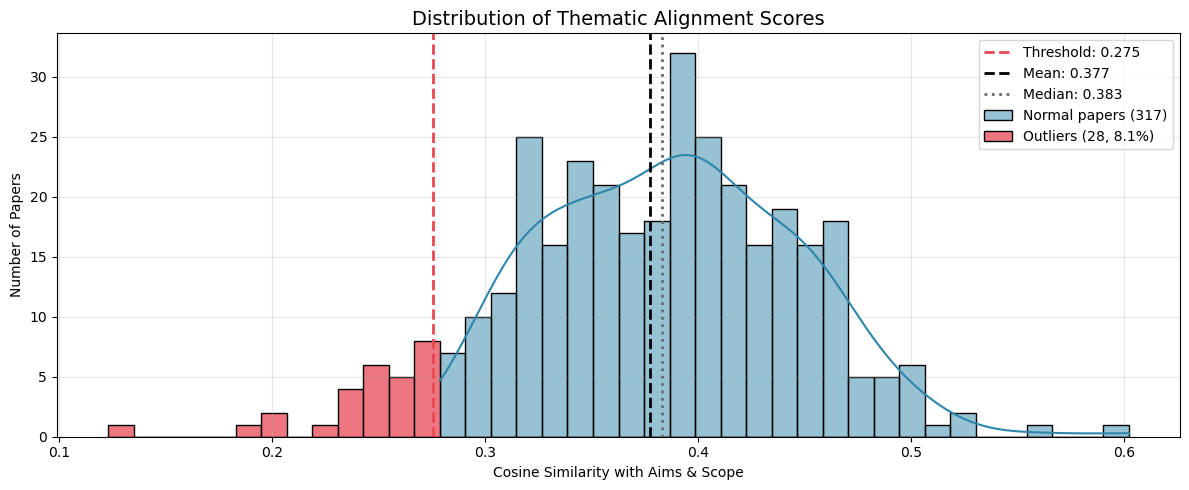

Saved: score_distribution.png


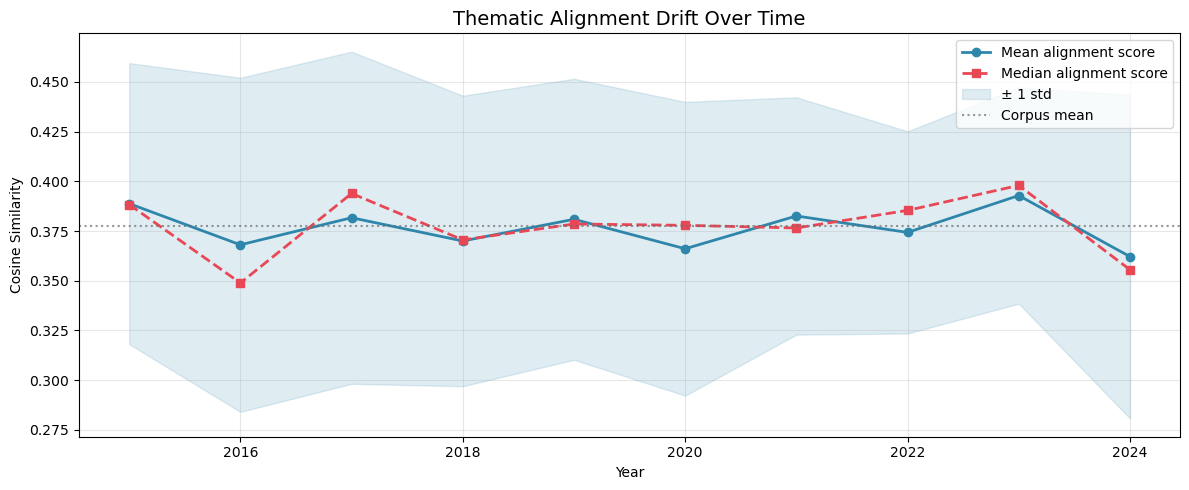

Saved: drift_over_time.png


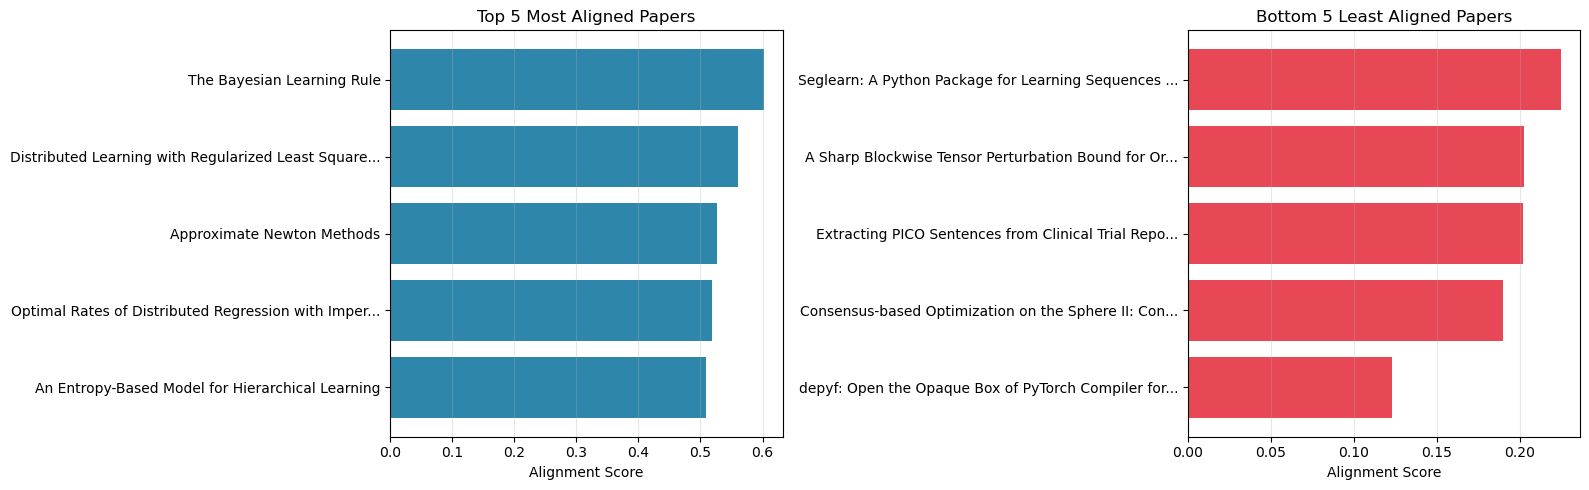

Saved: outliers.png


10it [00:00, 32.77it/s]


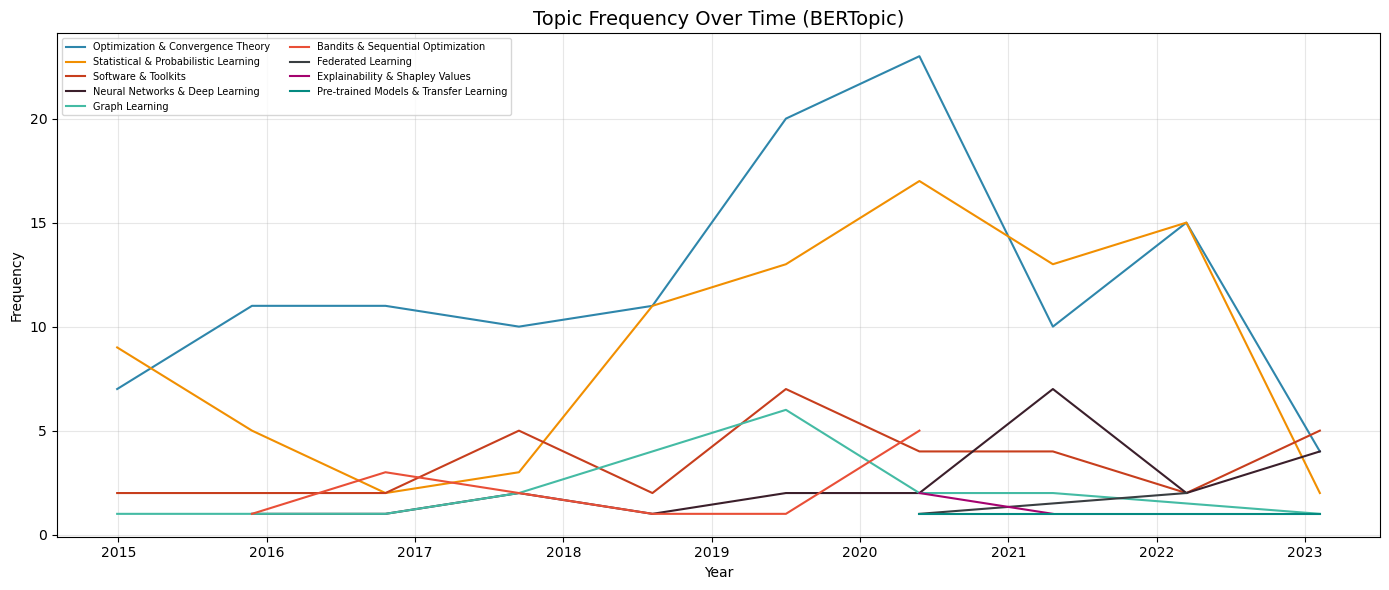

Saved: topics_over_time.png


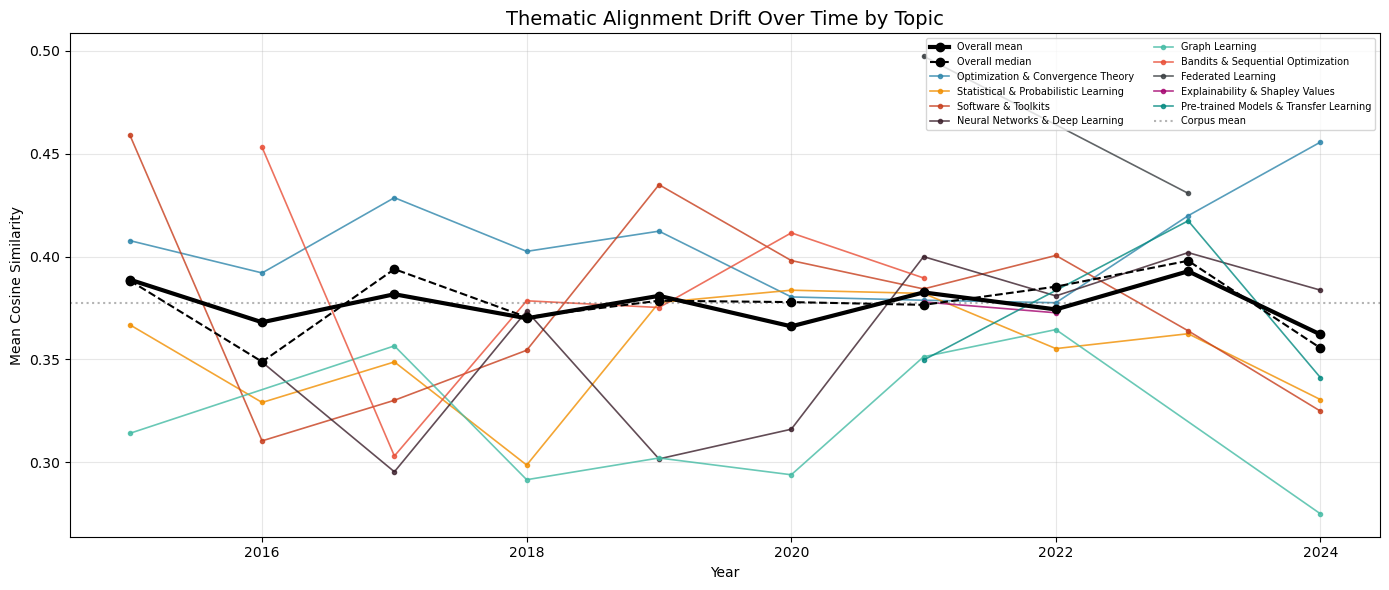

Saved: drift_by_topic.png


In [36]:
viz = Visualizer(output_dir="figures")

viz.plot_score_distribution(df, threshold=threshold)
viz.plot_drift_over_time(df)
viz.plot_outliers(top, bottom)

topics_over_time = topic_model.topics_over_time(
    abstracts, df["year"].tolist(), nr_bins=10
)
viz.plot_topics_over_time(topics_over_time, topic_names=topic_names)
viz.plot_drift_by_topic(df, topic_model, topic_names)